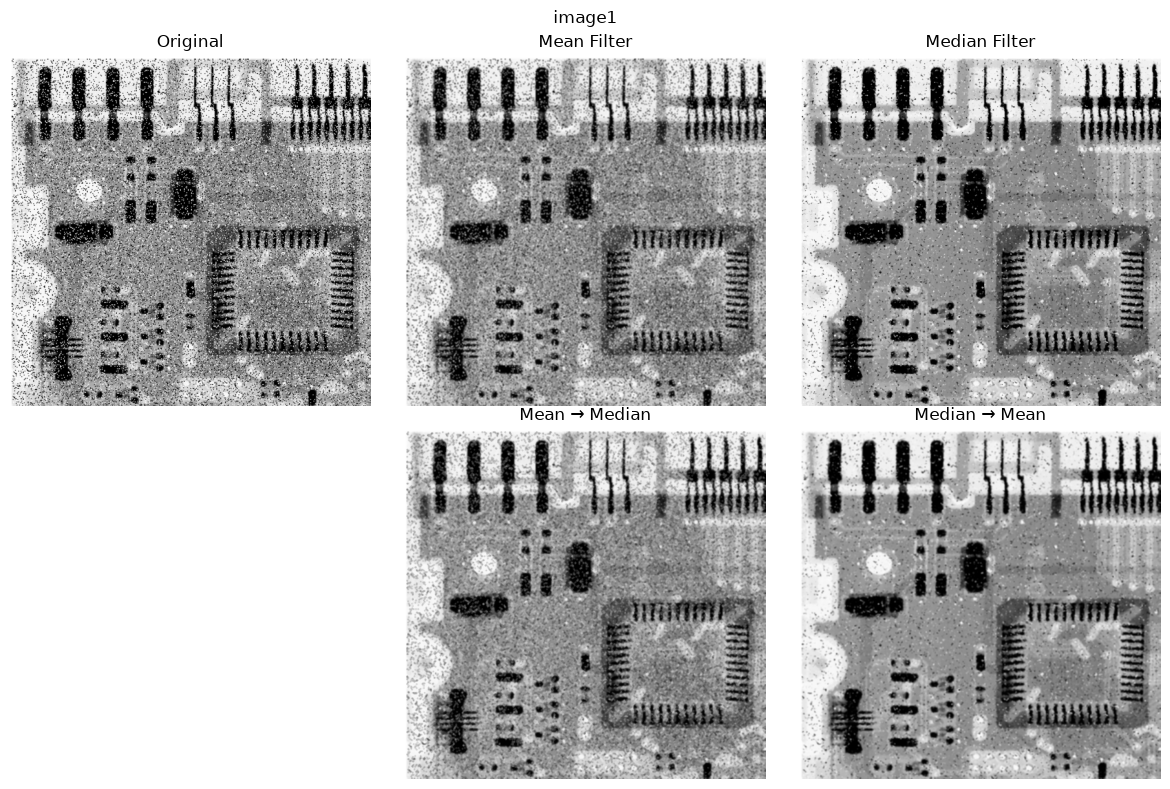

Processed: image1.png


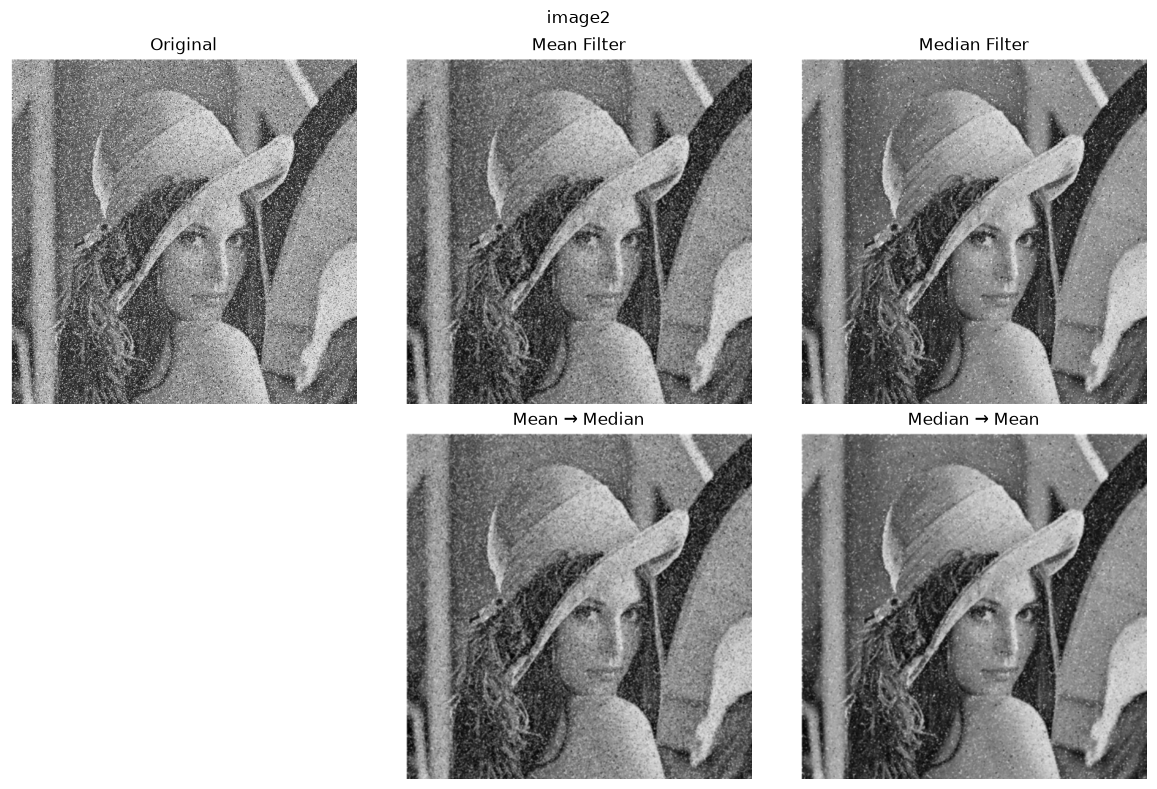

Processed: image2.png


In [1]:

import cv2
import matplotlib.pyplot as plt
import os

# ---------------------------------------------------------
# Configuration
# ---------------------------------------------------------

INPUT_IMAGES = [
    "image1.png",
    "image2.png"
]

KERNEL_SIZE = 3


# ---------------------------------------------------------
# Create output directory
# ---------------------------------------------------------

os.makedirs("output_builtin", exist_ok=True)


# ---------------------------------------------------------
# Process each image
# ---------------------------------------------------------

for image_path in INPUT_IMAGES:

    # Read image in grayscale
    image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

    if image is None:
        print("Error: Could not read", image_path)
        continue

    # -----------------------------------------------------
    # 1. Mean Filter
    # -----------------------------------------------------
    mean_image = cv2.blur(
        image,
        (KERNEL_SIZE, KERNEL_SIZE)
    )

    # -----------------------------------------------------
    # 2. Median Filter
    # -----------------------------------------------------
    median_image = cv2.medianBlur(
        image,
        KERNEL_SIZE
    )

    # -----------------------------------------------------
    # 3. Mean followed by Median
    # -----------------------------------------------------
    mean_median_image = cv2.medianBlur(
        mean_image,
        KERNEL_SIZE
    )

    # -----------------------------------------------------
    # 4. Median followed by Mean
    # -----------------------------------------------------
    median_mean_image = cv2.blur(
        median_image,
        (KERNEL_SIZE, KERNEL_SIZE)
    )

    # -----------------------------------------------------
    # Save results
    # -----------------------------------------------------

    name = os.path.splitext(
        os.path.basename(image_path)
    )[0]

    cv2.imwrite(
        f"output_builtin/{name}_mean.png",
        mean_image
    )

    cv2.imwrite(
        f"output_builtin/{name}_median.png",
        median_image
    )

    cv2.imwrite(
        f"output_builtin/{name}_mean_median.png",
        mean_median_image
    )

    cv2.imwrite(
        f"output_builtin/{name}_median_mean.png",
        median_mean_image
    )

    # -----------------------------------------------------
    # Display results
    # -----------------------------------------------------

    plt.figure(figsize=(12, 8))

    plt.subplot(2, 3, 1)
    plt.imshow(image, cmap="gray")
    plt.title("Original")
    plt.axis("off")

    plt.subplot(2, 3, 2)
    plt.imshow(mean_image, cmap="gray")
    plt.title("Mean Filter")
    plt.axis("off")

    plt.subplot(2, 3, 3)
    plt.imshow(median_image, cmap="gray")
    plt.title("Median Filter")
    plt.axis("off")

    plt.subplot(2, 3, 5)
    plt.imshow(mean_median_image, cmap="gray")
    plt.title("Mean → Median")
    plt.axis("off")

    plt.subplot(2, 3, 6)
    plt.imshow(median_mean_image, cmap="gray")
    plt.title("Median → Mean")
    plt.axis("off")

    plt.suptitle(name)

    plt.tight_layout()
    plt.show()

    print(f"Processed: {image_path}")

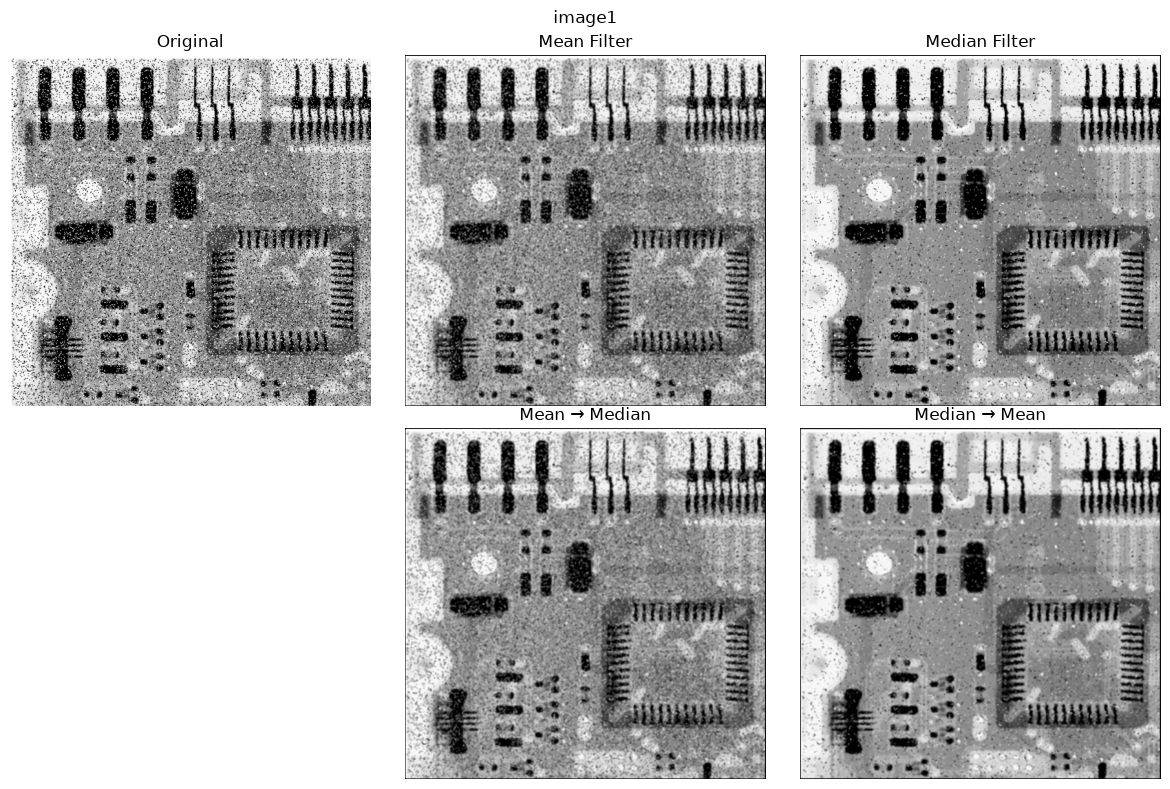

Processed: image1.png


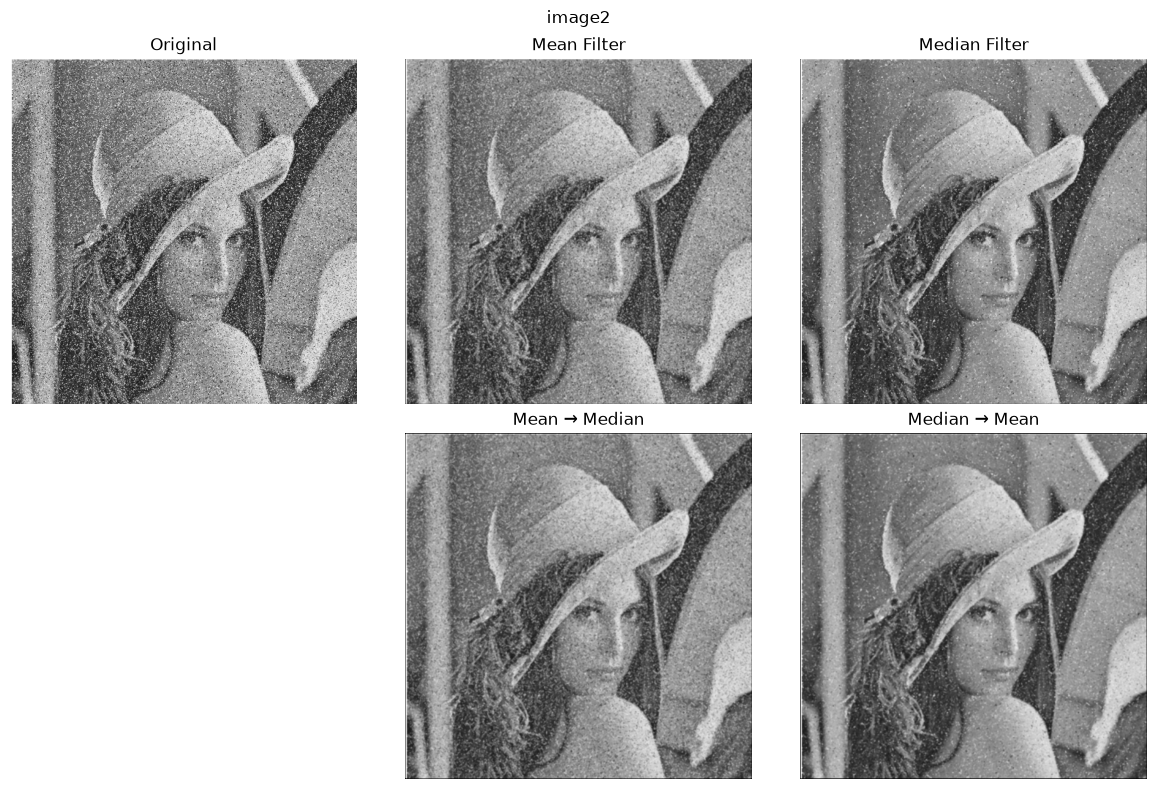

Processed: image2.png


In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os


# ---------------------------------------------------------
# Configuration
# ---------------------------------------------------------

INPUT_IMAGES = [
    "image1.png",
    "image2.png"
]

KERNEL_SIZE = 3


# ---------------------------------------------------------
# Manual Mean Filter
# ---------------------------------------------------------

def mean_filter(image, kernel_size=3):

    rows, cols = image.shape

    output = np.zeros_like(image)

    offset = kernel_size // 2

    for i in range(offset, rows - offset):

        for j in range(offset, cols - offset):

            total = 0

            # Visit every pixel in the neighborhood
            for ki in range(-offset, offset + 1):

                for kj in range(-offset, offset + 1):

                    total += int(
                        image[i + ki, j + kj]
                    )

            # Calculate average
            average = total // (kernel_size * kernel_size)

            output[i, j] = average

    return output


# ---------------------------------------------------------
# Manual Median Filter
# ---------------------------------------------------------

def median_filter(image, kernel_size=3):

    rows, cols = image.shape

    output = np.zeros_like(image)

    offset = kernel_size // 2

    for i in range(offset, rows - offset):

        for j in range(offset, cols - offset):

            pixels = []

            # Collect neighborhood pixels
            for ki in range(-offset, offset + 1):

                for kj in range(-offset, offset + 1):

                    pixels.append(
                        int(image[i + ki, j + kj])
                    )

            # Sort pixels manually
            pixels.sort()

            # Select middle element
            middle = len(pixels) // 2

            output[i, j] = pixels[middle]

    return output


# ---------------------------------------------------------
# Create output directory
# ---------------------------------------------------------

os.makedirs("output_manual", exist_ok=True)


# ---------------------------------------------------------
# Process each image
# ---------------------------------------------------------

for image_path in INPUT_IMAGES:

    # Read image
    image = cv2.imread(
        image_path,
        cv2.IMREAD_GRAYSCALE
    )

    if image is None:
        print("Error: Could not read", image_path)
        continue

    # -----------------------------------------------------
    # 1. Mean Filter
    # -----------------------------------------------------

    mean_image = mean_filter(
        image,
        KERNEL_SIZE
    )

    # -----------------------------------------------------
    # 2. Median Filter
    # -----------------------------------------------------

    median_image = median_filter(
        image,
        KERNEL_SIZE
    )

    # -----------------------------------------------------
    # 3. Mean followed by Median
    # -----------------------------------------------------

    mean_median_image = median_filter(
        mean_image,
        KERNEL_SIZE
    )

    # -----------------------------------------------------
    # 4. Median followed by Mean
    # -----------------------------------------------------

    median_mean_image = mean_filter(
        median_image,
        KERNEL_SIZE
    )

    # -----------------------------------------------------
    # Save results
    # -----------------------------------------------------

    name = os.path.splitext(
        os.path.basename(image_path)
    )[0]

    cv2.imwrite(
        f"output_manual/{name}_mean.png",
        mean_image
    )

    cv2.imwrite(
        f"output_manual/{name}_median.png",
        median_image
    )

    cv2.imwrite(
        f"output_manual/{name}_mean_median.png",
        mean_median_image
    )

    cv2.imwrite(
        f"output_manual/{name}_median_mean.png",
        median_mean_image
    )

    # -----------------------------------------------------
    # Display results
    # -----------------------------------------------------

    plt.figure(figsize=(12, 8))

    plt.subplot(2, 3, 1)
    plt.imshow(image, cmap="gray")
    plt.title("Original")
    plt.axis("off")

    plt.subplot(2, 3, 2)
    plt.imshow(mean_image, cmap="gray")
    plt.title("Mean Filter")
    plt.axis("off")

    plt.subplot(2, 3, 3)
    plt.imshow(median_image, cmap="gray")
    plt.title("Median Filter")
    plt.axis("off")

    plt.subplot(2, 3, 5)
    plt.imshow(mean_median_image, cmap="gray")
    plt.title("Mean → Median")
    plt.axis("off")

    plt.subplot(2, 3, 6)
    plt.imshow(median_mean_image, cmap="gray")
    plt.title("Median → Mean")
    plt.axis("off")

    plt.suptitle(name)

    plt.tight_layout()
    plt.show()

    print(f"Processed: {image_path}")